<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_ROOT = Path('/content/latent-ability-ml')
    if not REPO_ROOT.exists():
        subprocess.check_call([
            'git',
            'clone',
            'https://github.com/manuelfjr/latent-ability-ml.git',
            str(REPO_ROOT),
        ])

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'numpy',
        'pandas',
        'matplotlib',
        'scipy',
        'scikit-learn',
        'seaborn',
        'joblib',
        'tqdm',
        'birt-gd',
    ])

    for candidate in [REPO_ROOT, REPO_ROOT / 'notebooks', REPO_ROOT / 'utils', REPO_ROOT / 'src']:
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)

    from nb_utils import set_root
    PROJECT_ROOT = REPO_ROOT
    print(f'Running in Colab with project root: {PROJECT_ROOT}')
else:
    from nb_utils import set_root
    PROJECT_ROOT = set_root(level=2)
    print(f'Running locally with project root: {PROJECT_ROOT}')


**Environment note.** Run the setup cell above first. It loads the repository and the local modules needed for this notebook, especially when opening it in Google Colab.


# Section 2: Supervised Evaluation, Binary IRT, and 2PL ICCs

We begin from a familiar supervised evaluation problem: models are evaluated on labeled examples, but the examples are not equally difficult. Some examples are solved by almost every model, while others sit near ambiguous regions and reveal meaningful differences between models.

Binary IRT gives that intuition a formal language. Respondents have latent ability, items have latent difficulty and discrimination, and the response is a binary success/failure outcome.


## Learning Goals

By the end of this section, participants should be able to:

- explain why aggregate supervised metrics can hide example-level difficulty;
- interpret ability, difficulty, and discrimination;
- read an item characteristic curve (ICC);
- distinguish the 1PL intuition from the more flexible 2PL model;
- explain how IRT formalizes the idea that some examples are more informative than others.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from utils.handson import binary_irt_probability, make_binary_item_bank, plot_binary_iccs


## Step 1: From supervised examples to IRT items

In the supervised setting, a classifier can be read as a respondent and an example can be read as an item. Correct classification is the binary response. Easy examples are solved by most models, hard examples are missed or handled uncertainly by many models, and discriminative examples separate stronger models from weaker models.

The small item bank below makes that idea explicit on the 2PL latent scale. Ability and difficulty are real-valued; the plots use a practical window around the center of the scale.


In [21]:
item_bank = make_binary_item_bank()
item_bank


,item,difficulty,discrimination
0,easy_item,0.1,0.8
1,medium_item,0.5,1.2
2,hard_item,0.9,1.6


## Step 2: 1PL-style intuition

If we force every item to have the same discrimination, only difficulty changes. The curves shift left or right, but keep the same slope.


$$
x_{ij} \sim Bern(p_{ij})
$$

where

$$
E[x_{ij} | \theta_i, \delta_j, a_j] = p_{ij} = \frac{1}{1 + e^{-a_j \cdot (\theta_i - \delta_j)}}
$$

For 1PL case, it will be consider a<sub>j</sub>=1. So, we have:

$$
E[x_{ij} | \theta_i, \delta_j, a_j] = \frac{1}{1 + e^{-(\theta_i - \delta_j)}}
$$

In [ ]:
theta = np.linspace(-3.0, 3.0, 300)
one_pl_bank = item_bank.copy()
one_pl_bank['discrimination'] = 1.0


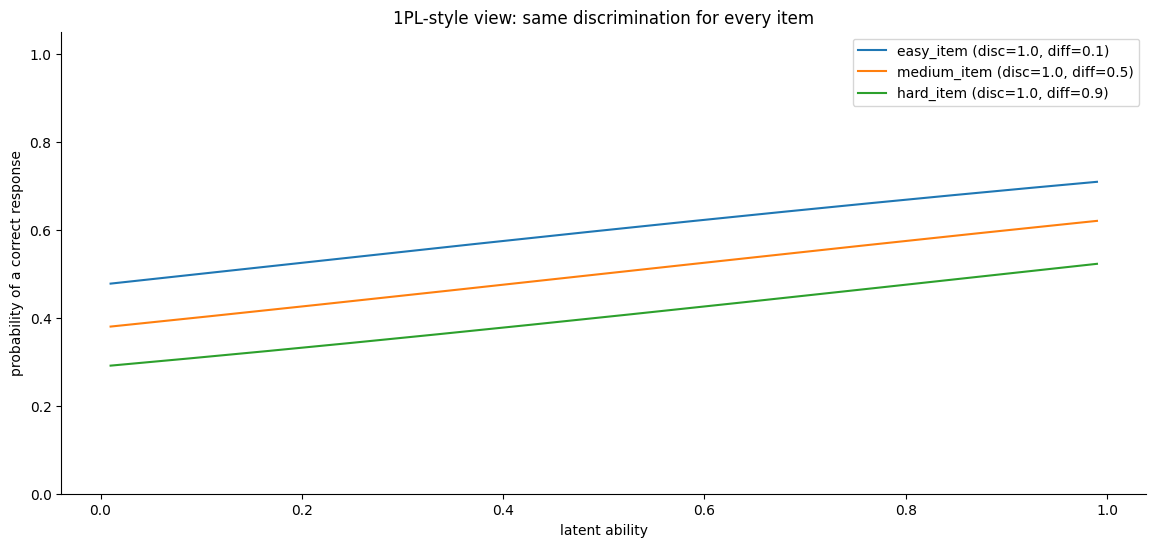

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))
ax = plot_binary_iccs(
    one_pl_bank,
    theta=theta,
    title='1PL-style view: same discrimination for every item',
    ax = ax
)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Step 3: 2PL curves

In 2PL, each item also has its own discrimination. This changes the slope of the ICC and tells us how sharply the item separates low- and high-ability respondents.


$$
x_{ij} \sim Bern(p_{ij})
$$

where

$$
E[x_{ij} | \theta_i, \delta_j, a_j] = p_{ij} = \frac{1}{1 + e^{-a_j \cdot (\theta_i - \delta_j)}}
$$

In [ ]:
item_bank_neg = make_binary_item_bank(
    [
        {"item": "easy_item", "difficulty": -1.0, "discrimination": -3},
        {"item": "medium_item", "difficulty": 0.0, "discrimination": -3},
        {"item": "hard_item", "difficulty": 1.0, "discrimination": -3},
    ]
)
item_bank_pos = make_binary_item_bank(
    [
        {"item": "easy_item", "difficulty": -1.0, "discrimination": 3},
        {"item": "medium_item", "difficulty": 0.0, "discrimination": 3},
        {"item": "hard_item", "difficulty": 1.0, "discrimination": 3},
    ]
)


In [ ]:
theta = np.linspace(-3.0, 3.0, 300)


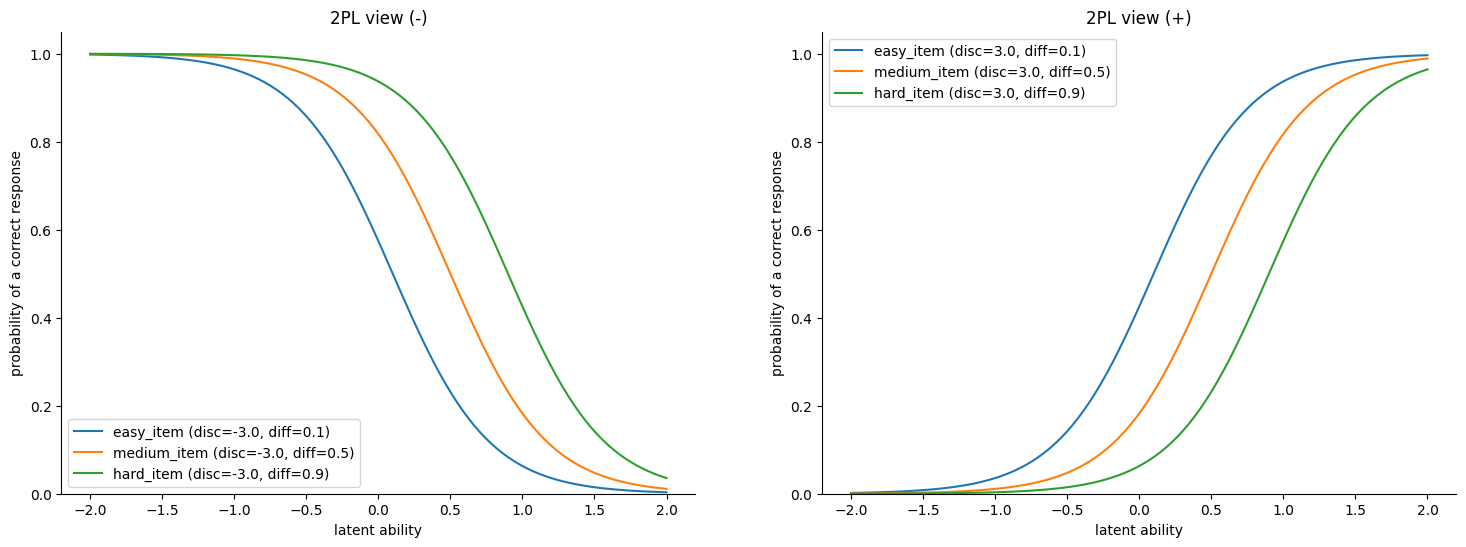

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
plot_binary_iccs(
    item_bank_neg,
    theta=theta,
    title='2PL view (-)',
    ax = ax[0]
)
plot_binary_iccs(
    item_bank_pos,
    theta=theta,
    title='2PL view (+)',
    ax = ax[1]
)
for _ax in ax:
    _ax.spines[["top", "right"]].set_visible(False)
plt.show()


In [27]:
item_bank = pd.concat([item_bank_neg, item_bank_pos], ignore_index=True)

In [ ]:
abis = [
    {"name": "model_low", "ability": -1.0},
    {"name": "model_mid", "ability": 0.0},
    {"name": "model_high", "ability": 1.0},
]
diff_disc = [
    {"item": "item_1", "difficulty": -1.0, "discrimination": 3},
    {"item": "item_2", "difficulty": 0.0, "discrimination": 3},
    {"item": "item_3", "difficulty": 1.0, "discrimination": 3},
    {"item": "item_4", "difficulty": -1.0, "discrimination": -3},
    {"item": "item_5", "difficulty": 0.0, "discrimination": -3},
    {"item": "item_6", "difficulty": 1.0, "discrimination": -3},
]
values = np.zeros(
    (len(diff_disc), len(abis))
)
for i, abi in enumerate(abis):
    for j, row in enumerate(diff_disc):
        p = binary_irt_probability(abi["ability"], row["difficulty"], row["discrimination"])
        values[j, i] = p
pij = pd.DataFrame(
    values,
    columns=[abi["name"] for abi in abis],
    index=[row["item"] for row in diff_disc]
)
pij.round(4)


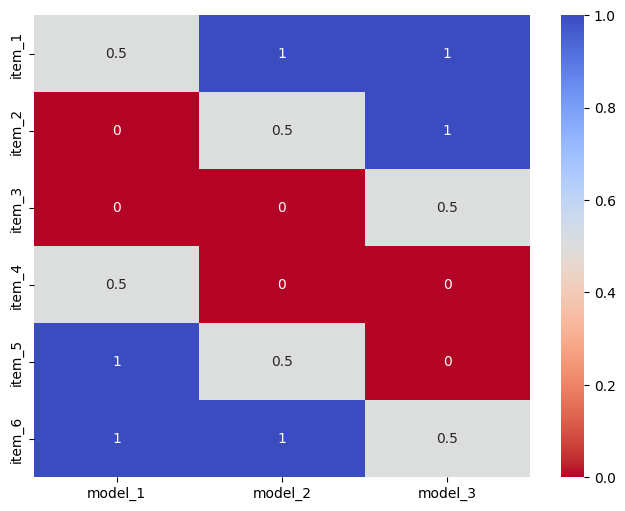

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pij.round(4), annot=True, cmap='coolwarm_r', ax=ax)
plt.show()

## Step 4: Hold difficulty fixed and vary discrimination

This is the cleanest way to explain what the `a_j` parameter does.


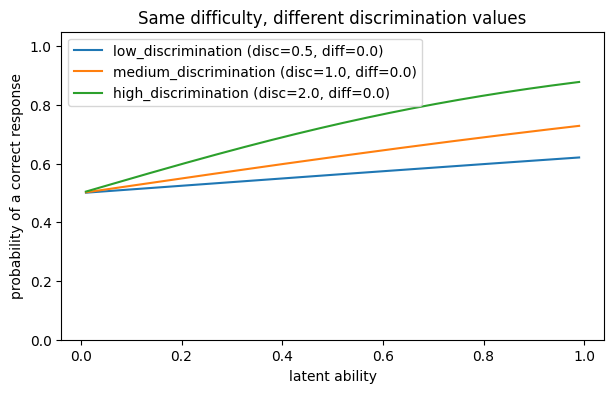

In [22]:
discrimination_demo = pd.DataFrame(
    [
        {'item': 'low_discrimination', 'difficulty': 0.0, 'discrimination': 0.5},
        {'item': 'medium_discrimination', 'difficulty': 0.0, 'discrimination': 1.0},
        {'item': 'high_discrimination', 'difficulty': 0.0, 'discrimination': 2.0},
    ]
)

ax = plot_binary_iccs(discrimination_demo, theta=theta, title='Same difficulty, different discrimination values')
plt.show()


## Reading the Curves

- Higher difficulty moves the curve to the right on the real-valued ability axis.
- Higher discrimination makes the transition sharper.
- When `theta = difficulty`, the success probability is around `0.5`.
- In the 2PL visualizations here, the ICCs are plotted over `theta` in `[-3, 3]`.
- ICCs describe *probability of success*, not a raw score.


## Bridge to Section 3

Logistic ICCs are excellent for intuition, but some AI evaluation settings use **continuous responses** rather than binary right-or-wrong outcomes. That motivates Beta-family IRT models, especially Beta4-IRT.
